In [51]:
import pandas as pd
import numpy as np
import seaborn as sns

In [71]:
# data = pd.concat([pd.read_csv('./recorded_data/exg_0.csv'), pd.read_csv('./recorded_data/exg_1.csv')])
data = pd.read_csv('./ds3/exg_0.csv')

for i in range(1, 6):
    data = pd.concat([data, pd.read_csv(f'./ds3/exg_{i}.csv')])

In [69]:
data = pd.read_csv('./normal/exg_0.csv')

for i in range(1, 3):
    data = pd.concat([data, pd.read_csv(f'./normal/exg_{i}.csv')])

In [61]:
data['timestamp'] = np.arange(len(data)) / 50

<Axes: xlabel='timestamp', ylabel='eeg'>

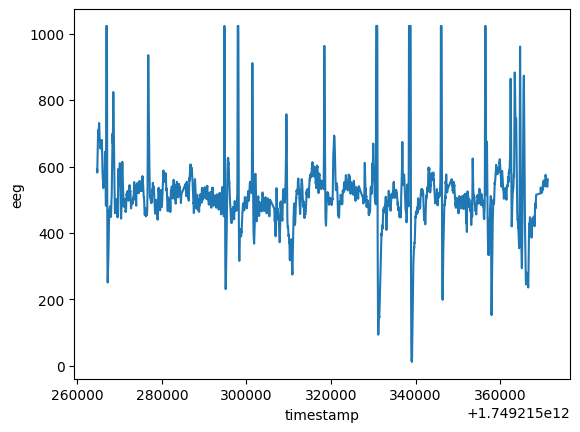

In [72]:
sns.lineplot(x=data.timestamp, y=data.eeg)

/home/aaditya/Projects/eeg/preprocessing/env/lib64/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/aaditya/Projects/eeg/preprocessing/env/lib64/python3.13/site-packages/pandas/core/dtypes/astype.py:133: ComplexWarning: Casting complex values to real discards the imaginary part
  return arr.astype(dtype, copy=True)


<Axes: >

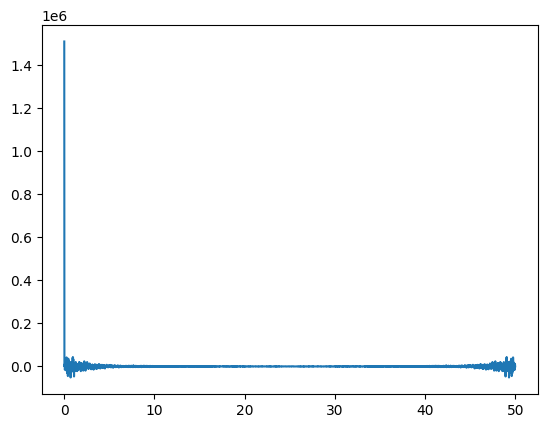

In [63]:
f = np.fft.fft(data.eeg)
sr = 50
N = len(f)

freq = np.arange(N) * sr / N

sns.lineplot(x=freq, y=f)

In [64]:
import neurokit2 as nk

d = nk.eeg.eeg_power(data[['eeg', 'timestamp']], 50)

<Axes: >

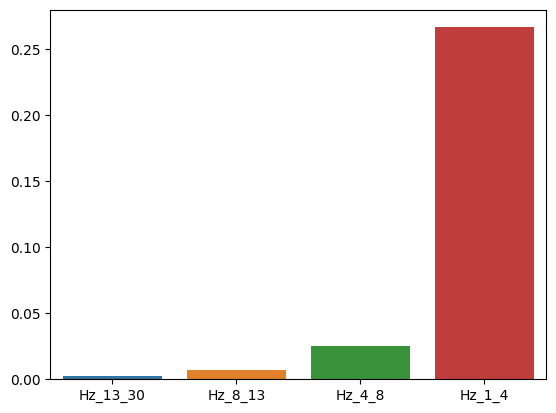

In [65]:
eeg_pow = d[["Hz_13_30", "Hz_8_13", "Hz_4_8", "Hz_1_4"]][:1]
sns.barplot(eeg_pow)

,Frequency,Power
4,0.039308,0.607939
5,0.049135,0.577289
6,0.058962,0.391516
7,0.068789,0.215778
8,0.078616,0.239790
...,...,...
2540,24.960692,0.000016
2541,24.970519,0.000029
2542,24.980346,0.000042
2543,24.990173,0.000050


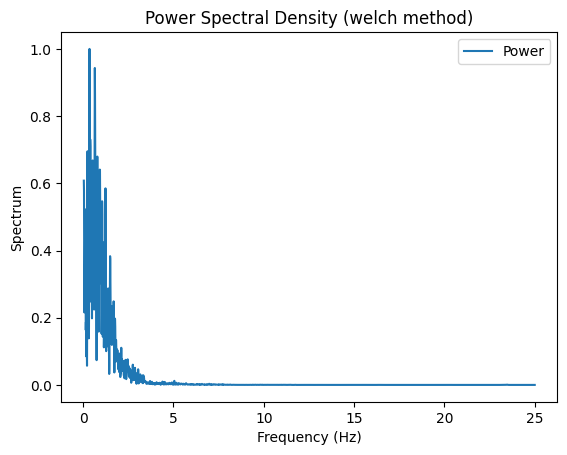

In [76]:
nk.signal_psd(data.eeg, 50, show=True)